## Purpose of this file:
read raw SIDER
extract PT-level drug–ADR labels
attach SIDER drug names
normalize SIDER drug names
read LINCS metadata
keep only small-molecule perturbations
normalize LINCS drug names
build clean SIDER ∩ LINCS label table
save one canonical label file

In [17]:
import re
from pathlib import Path

import pandas as pd

In [18]:
SIDER_RAW_PATH = "F:/CDSS/prototype4/raw_data/meddra_all_se.tsv"
SIDER_DRUG_NAMES_PATH = "F:/CDSS/prototype4/raw_data/drug_names.tsv"
LINCS_METADATA_PATH = "F:/CDSS/prototype4/raw_data/GSE92742_Broad_LINCS_inst_info.txt"

## Helper functions

In [20]:
SALT_WORDS = [
    "hydrochloride", "sodium", "potassium", "acetate",
    "sulfate", "phosphate", "tartrate", "succinate",
    "fumarate", "nitrate"
]

SALT_PATTERN = re.compile(r"\b(" + "|".join(SALT_WORDS) + r")\b")

def normalize(x):
    if pd.isna(x):
        return None
    x = str(x).lower()
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = SALT_PATTERN.sub(" ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x if x else None

### Load and Process SIDER

In [21]:
# Load drug names
drug_names = pd.read_csv(SIDER_DRUG_NAMES_PATH,
    sep="\t",
    header=None,
    names=["drug_id", "drug_name"],
    dtype=str
)

# Clean
drug_names["drug_id"] = drug_names["drug_id"].str.strip()
drug_names["drug_name"] = drug_names["drug_name"].str.strip()

# Remove duplicates (keep first valid name)
drug_names = (
    drug_names
    .dropna(subset=["drug_id", "drug_name"])
    .drop_duplicates(subset=["drug_id"], keep="first")
    .reset_index(drop=True)
)

print("Drug names loaded:", drug_names.shape)

Drug names loaded: (1430, 2)


In [22]:
sider_raw= pd.read_csv(SIDER_RAW_PATH, sep="\t", header=None, dtype=str)

# Keep PT level
sider = sider_raw[sider_raw[3] == "PT"][[0, 4, 5]].copy()
sider.columns = ["drug_id", "adr_id", "adr_name"]


In [23]:
# Merge names into SIDER
sider = sider.merge(
    drug_names,
    on="drug_id",
    how="left"
)

# Drop rows without names (cannot normalize/match later)
missing = sider["drug_name"].isna().sum()
print("Missing drug names:", missing)

sider = sider.dropna(subset=["drug_name"]).copy()

# Normalize names (use SAME function everywhere)
sider["drug_name_norm"] = sider["drug_name"].apply(normalize)

# Drop failed normalization
sider = sider.dropna(subset=["drug_name_norm"]).copy()

print("After merge:", sider.shape)
print("Unique drugs:", sider["drug_name_norm"].nunique())

Missing drug names: 0
After merge: (162519, 5)
Unique drugs: 1340


In [24]:
sider.head()

,drug_id,adr_id,adr_name,drug_name,drug_name_norm
0,CID100000085,C0000737,Abdominal pain,carnitine,carnitine
1,CID100000085,C0687713,Gastrointestinal pain,carnitine,carnitine
2,CID100000085,C0000737,Abdominal pain,carnitine,carnitine
3,CID100000085,C0002418,Amblyopia,carnitine,carnitine
4,CID100000085,C0002871,Anaemia,carnitine,carnitine


In [11]:
sider.to_csv("F:/CDSS/prototype4/outputs_sider_lincs/outsider_named_normalized.csv")

In [25]:
sider= pd.read_csv("F:/CDSS/prototype4/outputs_sider_lincs/outsider_named_normalized.csv")

### Load LINCS Metadata

In [26]:
lincs = pd.read_csv(LINCS_METADATA_PATH, sep="\t", dtype=str)

# Keep only small molecule drugs
lincs = lincs[lincs["pert_type"] == "trt_cp"].copy()

lincs["pert_iname"] = lincs["pert_iname"].str.strip()
lincs["drug_name_norm"] = lincs["pert_iname"].apply(normalize)

lincs = lincs.dropna(subset=["drug_name_norm"])

print("LINCS shape:", lincs.shape)
print("Unique drugs:", lincs["drug_name_norm"].nunique())

LINCS shape: (672128, 12)
Unique drugs: 19798


In [7]:
lincs.head()

,inst_id,rna_plate,rna_well,pert_id,pert_iname,pert_type,pert_dose,pert_dose_unit,pert_time,pert_time_unit,cell_id,drug_name_norm
12,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:A06,ASG001_MCF7_24H_X1,A06,BRD-A60070924,alpha-estradiol,trt_cp,10.0,um,24,h,MCF7,alpha estradiol
13,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:B06,ASG001_MCF7_24H_X1,B06,BRD-A60070924,alpha-estradiol,trt_cp,2.0,um,24,h,MCF7,alpha estradiol
14,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:C06,ASG001_MCF7_24H_X1,C06,BRD-A60070924,alpha-estradiol,trt_cp,0.4,um,24,h,MCF7,alpha estradiol
15,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:D06,ASG001_MCF7_24H_X1,D06,BRD-A60070924,alpha-estradiol,trt_cp,0.08,um,24,h,MCF7,alpha estradiol
16,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:E06,ASG001_MCF7_24H_X1,E06,BRD-A60070924,alpha-estradiol,trt_cp,10.0,um,24,h,MCF7,alpha estradiol


## Compute Intersection

In [27]:
import pubchempy as pcp
import pandas as pd
from tqdm import tqdm

In [28]:
lincs_unique = (
    lincs[["drug_name_norm"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print("LINCS unique drugs:", len(lincs_unique))

LINCS unique drugs: 19798


In [ ]:
# def resolve_to_cid(name):
#     try:
#         compounds = pcp.get_compounds(name, "name")
#         if compounds:
#             return compounds[0].cid
#     except Exception:
#         return compounds[]
#     return None

In [29]:

import gzip
from tqdm import tqdm

lincs_names = set(lincs["drug_name_norm"].dropna().unique())

name_to_cid = {}

with gzip.open("F:/CDSS/prototype4/raw_data/CID-Synonym-filtered.gz", "rt") as f:
    for line in tqdm(f):
        try:
            cid, synonym = line.strip().split("\t")

            # normalize inline (same as your pipeline)
            syn = synonym.lower()
            syn = re.sub(r"[^a-z0-9\s]", " ", syn)
            syn = re.sub(r"\s+", " ", syn).strip()

            if syn in lincs_names:
                name_to_cid[syn] = int(cid)

        except:
            continue

116258302it [08:05, 239639.34it/s]


In [30]:
lincs["cid"] = lincs["drug_name_norm"].map(name_to_cid)

lincs_with_cid = lincs.dropna(subset=["cid"])
lincs_with_cid["cid"] = lincs_with_cid["cid"].astype(int)

print("Resolved LINCS:", len(lincs_with_cid))

Resolved LINCS: 325350


C:\Users\ramru\AppData\Local\Temp\ipykernel_17888\1143398666.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lincs_with_cid["cid"] = lincs_with_cid["cid"].astype(int)


In [13]:
lincs_with_cid.to_csv("F:/CDSS/prototype4/outputs_sider_lincs/lincs_with_cid.csv")

In [31]:
lincs= pd.read_csv("F:/CDSS/prototype4/outputs_sider_lincs/lincs_with_cid.csv")

In [14]:
lincs_with_cid.head()

,inst_id,rna_plate,rna_well,pert_id,pert_iname,pert_type,pert_dose,pert_dose_unit,pert_time,pert_time_unit,cell_id,drug_name_norm,cid
12,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:A06,ASG001_MCF7_24H_X1,A06,BRD-A60070924,alpha-estradiol,trt_cp,10.0,um,24,h,MCF7,alpha estradiol,6432565
13,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:B06,ASG001_MCF7_24H_X1,B06,BRD-A60070924,alpha-estradiol,trt_cp,2.0,um,24,h,MCF7,alpha estradiol,6432565
14,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:C06,ASG001_MCF7_24H_X1,C06,BRD-A60070924,alpha-estradiol,trt_cp,0.4,um,24,h,MCF7,alpha estradiol,6432565
15,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:D06,ASG001_MCF7_24H_X1,D06,BRD-A60070924,alpha-estradiol,trt_cp,0.08,um,24,h,MCF7,alpha estradiol,6432565
16,ASG001_MCF7_24H_X1_B7_DUO52HI53LO:E06,ASG001_MCF7_24H_X1,E06,BRD-A60070924,alpha-estradiol,trt_cp,10.0,um,24,h,MCF7,alpha estradiol,6432565


In [17]:
sider.head()

,Unnamed: 0,drug_id,adr_id,adr_name,drug_name,drug_name_norm
0,0,CID100000085,C0000737,Abdominal pain,carnitine,carnitine
1,1,CID100000085,C0687713,Gastrointestinal pain,carnitine,carnitine
2,2,CID100000085,C0000737,Abdominal pain,carnitine,carnitine
3,3,CID100000085,C0002418,Amblyopia,carnitine,carnitine
4,4,CID100000085,C0002871,Anaemia,carnitine,carnitine


In [ ]:
# def extract_true_cid(stitch_id):
#     if pd.isna(stitch_id):
#         return None

#     s = str(stitch_id)

#     # Remove prefix
#     if s.startswith("CID"):
#         s = s[3:]
#     try:
#         return int(s)
#     except:
#         return None
    

In [ ]:
# sider["drug_cid"] = sider["drug_id"].apply(extract_true_cid)

In [6]:
sider.head()

,Unnamed: 0,drug_id,adr_id,adr_name,drug_name,drug_name_norm
0,0,CID100000085,C0000737,Abdominal pain,carnitine,carnitine
1,1,CID100000085,C0687713,Gastrointestinal pain,carnitine,carnitine
2,2,CID100000085,C0000737,Abdominal pain,carnitine,carnitine
3,3,CID100000085,C0002418,Amblyopia,carnitine,carnitine
4,4,CID100000085,C0002871,Anaemia,carnitine,carnitine


In [32]:
sider_names = set(sider["drug_name_norm"].dropna().unique())

print("SIDER unique names:", len(sider_names))

SIDER unique names: 1340


In [34]:
sider_name_to_cid = {}

with gzip.open("F:/CDSS/prototype4/raw_data/CID-Synonym-filtered.gz", "rt") as f:
    for line in tqdm(f):
        try:
            cid, synonym = line.strip().split("\t")

            # normalize EXACTLY same as your pipeline
            syn = synonym.lower()
            syn = re.sub(r"[^a-z0-9\s]", " ", syn)
            syn = re.sub(r"\s+", " ", syn).strip()

            if syn in sider_names:
                # only set once (avoid overwriting)
                if syn not in sider_name_to_cid:
                    sider_name_to_cid[syn] = int(cid)

            # optional early stop
            if len(sider_name_to_cid) == len(sider_names):
                break

        except:
            continue

116258302it [08:01, 241627.65it/s]


In [35]:
sider["cid"] = sider["drug_name_norm"].map(sider_name_to_cid)

sider_with_cid = sider.dropna(subset=["cid"]).copy()
sider_with_cid["cid"] = sider_with_cid["cid"].astype(int)

print("SIDER with CID:", sider_with_cid.shape)
print("Resolved SIDER drugs:", sider_with_cid["drug_name_norm"].nunique())

SIDER with CID: (155532, 7)
Resolved SIDER drugs: 1266


In [36]:
final = sider_with_cid.merge(
    lincs_with_cid,
    on="cid",
    how="inner"
)

final = final[
    [
        "drug_id",
        "cid",
        "drug_name",
        "drug_name_norm_x",
        "pert_id",
        "pert_iname",
        "adr_id",
        "adr_name"
    ]
].drop_duplicates()

In [37]:
print("Final shape:", final.shape)
print("Unique drugs:", final["drug_name_norm_x"].nunique())
print("Unique ADRs:", final["adr_id"].nunique())

Final shape: (106173, 8)
Unique drugs: 583
Unique ADRs: 3366


In [46]:
final.to_csv("F:/CDSS/prototype4/outputs_sider_lincs/sider_lincs_labels_cid.csv", index=False)

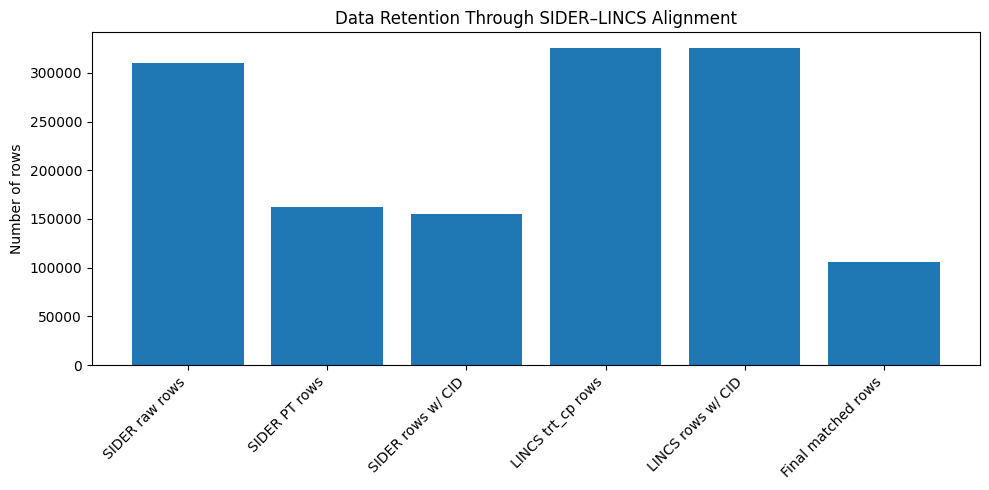

In [38]:
import matplotlib.pyplot as plt

stats = {
    "SIDER raw rows": len(sider_raw),
    "SIDER PT rows": len(sider),
    "SIDER rows w/ CID": len(sider_with_cid),
    "LINCS trt_cp rows": len(lincs),
    "LINCS rows w/ CID": len(lincs_with_cid),
    "Final matched rows": len(final),
}

plt.figure(figsize=(10, 5))
plt.bar(stats.keys(), stats.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of rows")
plt.title("Data Retention Through SIDER–LINCS Alignment")
plt.tight_layout()
plt.show()